# 1. Exploratory Data Analysis (EDA)

### EDA

In this step, we import the main libraries used for data analysis:
- Pandas is used to load and manipulate the dataset.
- NumPy helps with numerical operations.
- Matplotlib and Seaborn are used to create visualizations.

After importing the libraries, we load the training dataset using pd.read_csv().
The head() function displays the first few rows of the dataset so we can quickly verify that the data was loaded correctly and see the structure of the features.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("train_carbreakdown.csv")

# Preview first rows
df.head()

ModuleNotFoundError: No module named 'pandas'

The shape function tells us how many rows and columns are present in the dataset.
- Rows represent individual vehicles
- Columns represent features describing each vehicle

The info() function gives more detailed information about the dataset:
-  Data types of each column (numerical or categorical)
- Number of non-missing values
- Memory usage

This helps us determine which features may require preprocessing later.

In [ ]:
# Check dataset dimensions
df.shape

# Inspect data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1050 non-null   int64  
 1   vehicle_brand              1029 non-null   object 
 2   vehicle_age_years          1034 non-null   float64
 3   mileage_km                 1033 non-null   float64
 4   engine_hours               1035 non-null   float64
 5   last_service_km_ago        1040 non-null   float64
 6   oil_quality_pct            1014 non-null   float64
 7   avg_trip_length_km         1038 non-null   float64
 8   weather_exposure           1037 non-null   object 
 9   fuel_type                  1036 non-null   object 
 10  cleanliness_score          995 non-null    float64
 11  driver_satisfaction_score  1037 non-null   float64
 12  tyre_type                  1033 non-null   object 
 13  breakdown_next_30_days     1050 non-null   int64

Missing data can negatively affect machine learning models.
The isnull().sum() function counts how many missing values exist in each column.

If missing values are found, we will later handle them using imputation techniques, such as replacing them with the median for numerical features or the most frequent category for categorical features.

In [ ]:
# Count missing values per column
df.isnull().sum()

id                            0
vehicle_brand                21
vehicle_age_years            16
mileage_km                   17
engine_hours                 15
last_service_km_ago          10
oil_quality_pct              36
avg_trip_length_km           12
weather_exposure             13
fuel_type                    14
cleanliness_score            55
driver_satisfaction_score    13
tyre_type                    17
breakdown_next_30_days        0
dtype: int64

The target variable in this project is breakdown_next_30_days, which indicates whether a car will break down within the next 30 days.
- 0 → No breakdown expected
- 1 → Breakdown expected

The value_counts() function shows how many observations belong to each class.

Using normalize=True converts these counts into percentages, allowing us to see whether the dataset is balanced or imbalanced.
Class imbalance can affect model performance and may require special handling during training.

In [ ]:
# Count occurrences of each class
df['breakdown_next_30_days'].value_counts()

# Percentage distribution of classes
df['breakdown_next_30_days'].value_counts(normalize=True)

breakdown_next_30_days
0    0.832381
1    0.167619
Name: proportion, dtype: float64

The describe() function provides statistical summaries for numerical variables, including:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles (25%, 50%, 75%)

This helps us understand the typical range of each feature and detect unusual values.

In [ ]:
df.describe()

,id,vehicle_age_years,mileage_km,engine_hours,last_service_km_ago,oil_quality_pct,avg_trip_length_km,cleanliness_score,driver_satisfaction_score,breakdown_next_30_days
count,1050.000000,1034.000000,1.033000e+03,1035.000000,1040.000000,1014.000000,1038.000000,995.000000,1037.000000,1050.000000
mean,742.984762,9.399420,3.639119e+06,4368.929467,10681.075986,60.682779,38.861387,69.393768,6.972183,0.167619
std,430.089010,5.752228,2.585818e+07,2214.510223,9341.969609,20.298624,47.968702,15.570872,1.478278,0.373706
min,0.000000,0.000000,-1.829042e+02,-50.000000,10.869020,0.000000,1.011100,-13.171570,2.504369,0.000000
25%,372.250000,5.000000,8.338616e+04,2773.353090,3374.773323,47.377582,8.187057,58.902723,6.001099,0.000000
50%,740.500000,9.000000,1.202357e+05,3967.125562,8085.318122,60.528422,16.788852,69.504547,6.928004,0.000000
75%,1109.250000,14.000000,1.674871e+05,5432.498224,14455.318280,74.654436,44.308719,79.597898,8.022503,0.000000
max,1498.000000,20.000000,3.734539e+08,10298.582128,40592.195120,102.548055,201.015553,144.139920,10.291940,1.000000


Histograms allow us to visualize the distribution of numerical variables.

This helps us identify:
- Skewed distributions
- Extreme values
- Possible outliers
- Differences in feature ranges

Understanding feature distributions is important when preparing data for machine learning models.

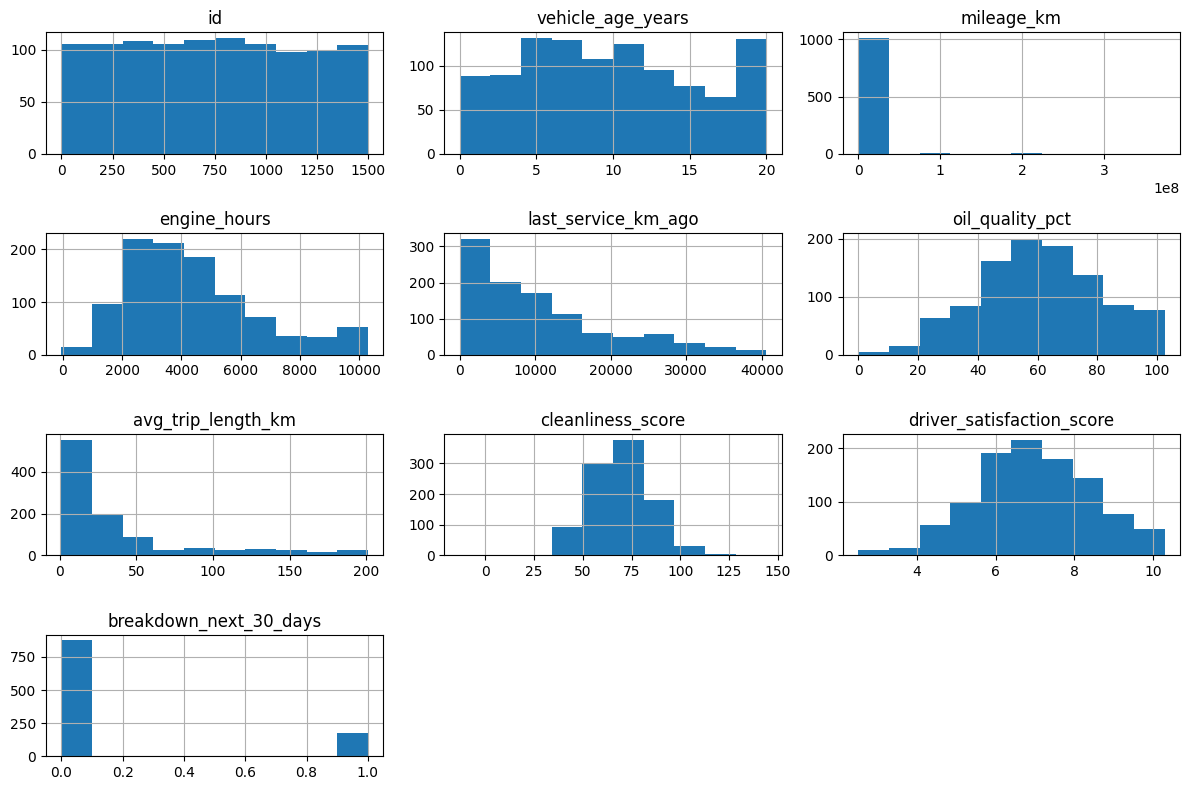

In [ ]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Boxplots are used to identify outliers in numerical features.
Outliers appear as points outside the whiskers of the boxplot and represent values that are much higher or lower than most observations.
In vehicle data, outliers may occur due to:
- Extremely high mileage
- Unusual engine usage
- Rare maintenance conditions

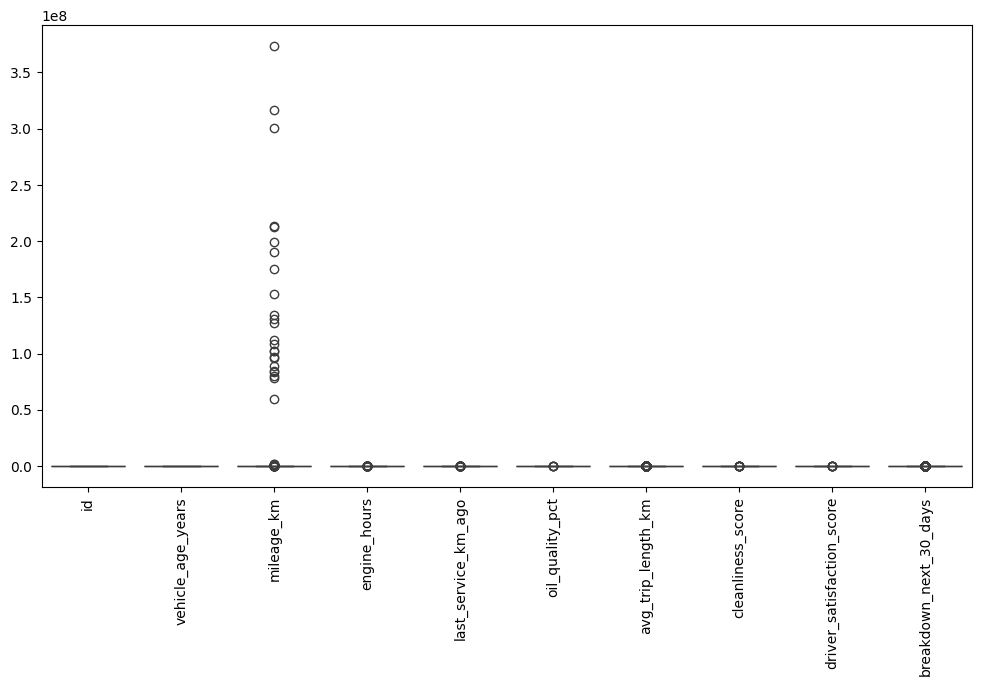

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

This analysis examines the distribution of the fuel_type variable.

The value_counts() function shows how many vehicles belong to each fuel category.
The countplot() visualization makes it easier to compare the frequencies visually.

Understanding categorical distributions helps determine whether certain categories dominate the dataset.

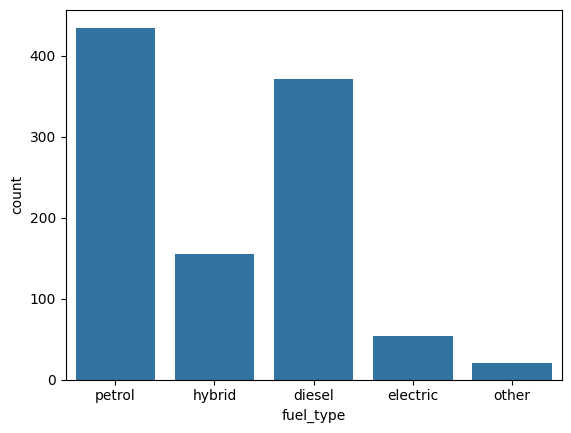

In [ ]:
df['fuel_type'].value_counts()

sns.countplot(x='fuel_type', data=df)
plt.show()

This analysis investigates whether vehicles with higher mileage are more likely to break down.

The boxplot compares the mileage distribution for vehicles that break down versus those that do not.

The groupby() function calculates the average mileage for each class, helping us determine if mileage is an important predictor of breakdown risk.

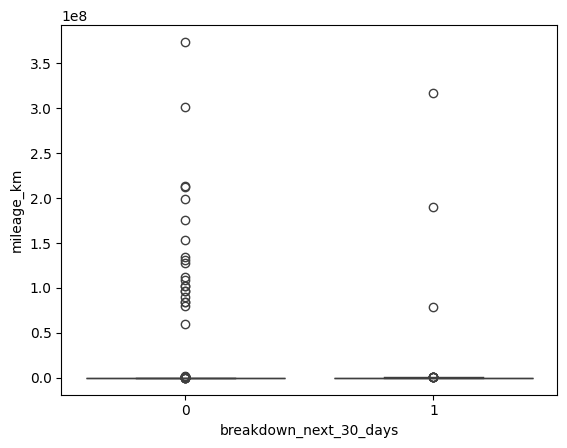

breakdown_next_30_days
0    3.674587e+06
1    3.466412e+06
Name: mileage_km, dtype: float64

In [ ]:
sns.boxplot(x='breakdown_next_30_days', y='mileage_km', data=df)
plt.show()

df.groupby('breakdown_next_30_days')['mileage_km'].mean()

Here we explore whether breakdown probability varies by fuel type.

The crosstab() table calculates the proportion of breakdowns within each fuel category.
The bar plot visualizes the average breakdown rate per fuel type, which may reveal patterns related to engine technology or vehicle usage.

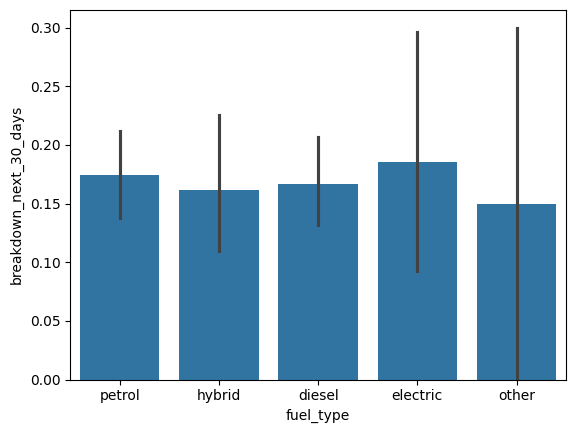

In [ ]:
pd.crosstab(df['fuel_type'], df['breakdown_next_30_days'], normalize='index')

sns.barplot(x='fuel_type', y='breakdown_next_30_days', data=df)
plt.show()

Correlation analysis helps identify relationships between numerical features.

The heatmap displays correlation values between variables:
- Values close to 1 or -1 indicate strong relationships
- Values close to 0 indicate weak relationships

This analysis helps detect:
- Features that may influence breakdown risk
- Variables that are strongly related to each other (multicollinearity)

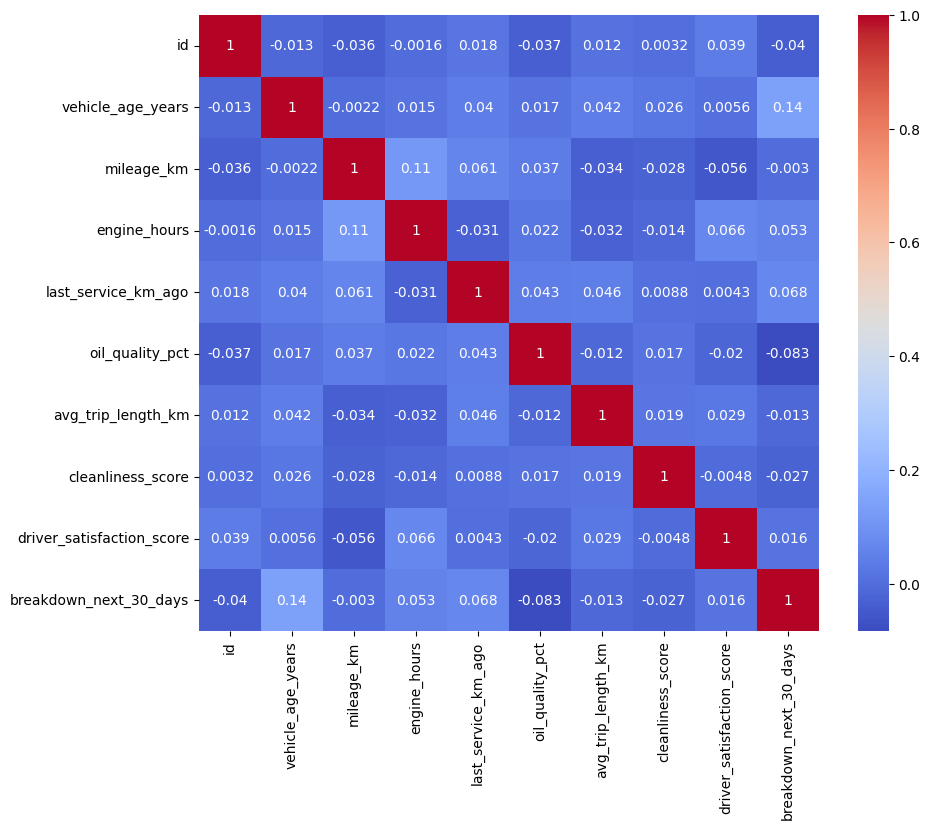

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# 2. Modeling Pipeline

In [ ]:
!pip install numpy pandas matplotlib scikit-learn seaborn jupyter

Defaulting to user installation because normal site-packages is not writeable
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------- ----- 786.4/914.9 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 5.6 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.4 MB 8.1 MB/s eta 0:00:02
   ----------- ---------------------------- 3.7/12.4 MB 9.0 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.4 MB 8.6 MB/s eta 0:00:01
   ----------------------- ---------------- 7.3/1

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

These libraries are part of Scikit-learn, which is used for building machine learning models.

Main components:
- train_test_split

   Splits the dataset into training and validation sets.
- ColumnTransformer

   Applies different preprocessing steps to different types of features.
- Pipeline

   Combines preprocessing and modeling steps into a single workflow.

- SimpleImputer

   Handles missing values in the dataset.

- OneHotEncoder

   Converts categorical variables into numerical format so the model can process them.

- RandomForestClassifier

   A machine learning algorithm that builds multiple decision trees and combines them to make predictions.

- Evaluation metrics
   - accuracy_score
   - confusion_matrix
   - classification_report

These help measure how well the model performs.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ModuleNotFoundError: No module named 'sklearn'

Machine learning models require a clear separation between:
- Features (X) → Input variables used for prediction
- Target (y) → The variable we want to predict

In this case:
- X contains vehicle information (mileage, oil quality, fuel type, etc.)
- y contains the breakdown indicator (0 or 1)

In [10]:
TARGET = "breakdown_next_30_days"

y = df[TARGET]
X = df.drop(columns=[TARGET])

NameError: name 'df' is not defined

The dataset is divided into:
- Training set (80%) → used to train the model
- Validation set (20%) → used to evaluate model performance

The parameter stratify=y ensures that the proportion of breakdowns (0 and 1) remains the same in both sets.

The random_state ensures reproducibility so that the split remains consistent every time the code runs.

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

NameError: name 'train_test_split' is not defined

Different types of variables require different preprocessing methods.

This step automatically separates the dataset into:

Numerical features, such as:
- mileage_km
- engine_hours
- oil_quality_pct
- vehicle_age_years

Categorical features, such as:
- vehicle_brand
- fuel_type
- tyre_type
- weather_exposure

Handling them separately improves model performance.

In [ ]:
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

Preprocessing ensures the data is clean and usable for machine learning.

For numerical variables:
- Missing values are replaced with the median value.
- The median is preferred because it is less sensitive to extreme values.

For categorical variables:
- Missing values are replaced with the most frequent category
- The categorical variables are converted into numbers using One-Hot Encoding

One-Hot Encoding creates binary columns representing each category.

Example:

fuel_type

fuel_type	petrol	diesel	hybrid
petrol	1	0	0

The parameter handle_unknown="ignore" ensures the model does not crash if new categories appear in the test set.

In [ ]:
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

The ColumnTransformer applies the appropriate preprocessing to each type of feature:
- Numerical columns → median imputation
- Categorical columns → most frequent imputation + one-hot encoding

This ensures that each feature is transformed correctly before entering the model.

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

The Random Forest algorithm is used as the baseline model.

Random Forest works by creating many decision trees and combining their predictions.

Important parameters:

- n_estimators=800

    The number of trees in the forest. More trees generally improve stability.

- class_weight="balanced"
    
    Helps handle class imbalance by giving more weight to the minority class.

- max_features="sqrt"
    
    Each tree considers only a subset of features when splitting.

- min_samples_leaf=2
    
    Prevents trees from becoming too complex and reduces overfitting.

- n_jobs=-1

    Uses all available CPU cores to speed up training.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
    class_weight="balanced",
    max_features="sqrt",
    min_samples_leaf=2,
    n_jobs=-1
)

The pipeline combines preprocessing and model training into one workflow.

Steps executed during training:
- Handle missing values
- Encode categorical features
- Train the Random Forest model

This approach ensures that the exact same preprocessing is applied to both training and test data.

In [ ]:
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

The model is trained using the training dataset.

During this step:
- Data is automatically preprocessed
- The Random Forest algorithm learns patterns from the features
- The model attempts to distinguish vehicles that will break down from those that will not.

In [ ]:
model.fit(X_train, y_train)

After training, the model is evaluated using the validation dataset.

Metrics used:

Accuracy

Measures the percentage of correct predictions.

Confusion Matrix

Shows how predictions are distributed:

	Predicted 0	Predicted 1
Actual 0	True Negatives	False Positives
Actual 1	False Negatives	True Positives

This matrix helps understand which mistakes the model makes.

Classification Report

Provides additional metrics:
- Precision → how reliable positive predictions are
- Recall → how many real breakdowns the model detects
- F1-score → balance between precision and recall

These metrics provide a more detailed evaluation than accuracy alone.

In [ ]:
y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

print("Validation Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_val, y_pred))

After validating the model, we train it again using the entire training dataset.

This allows the model to learn from all available data before making predictions on the test dataset.

In [ ]:
model.fit(X, y)

Finally, predictions are generated for the test dataset.

Steps performed:
- Load the test dataset
- Use the trained model to predict breakdowns
- Insert predictions into the sample submission format
- Save the results as submission.csv

This file can then be uploaded to Kaggle to obtain the competition score.

In [ ]:
test_df = pd.read_csv("test_carbreakdown.csv")
sample_sub = pd.read_csv("sample_submission.csv")

test_pred = model.predict(test_df)

submission = sample_sub.copy()
submission[TARGET] = test_pred

submission.to_csv("submission.csv", index=False)

submission.head()

# 3. Random Forest Model as a Baseline 
### (one or moer additional modeling approaches)

# 4. Proper Evaluation of Each Model
### (including a confusion matrix)

# 5. GenAI Section

# 6. Notes (will be deleted at the end)

- make **tree graph**
- suppervised learning